In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    ) 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="googlenet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.14416745797906602,train_accu=0.9563428571428572
Epoch=0,valid_loss=0.20914178774952888,valid_accu=0.9304
0
Epoch=1,train_loss=0.07885332614438874,train_accu=0.9766571428571429
Epoch=1,valid_loss=0.1695397354900837,valid_accu=0.9413
0
Epoch=2,train_loss=0.05622349826182638,train_accu=0.9836857142857143
Epoch=2,valid_loss=0.17160114684700967,valid_accu=0.9425
0
Epoch=3,train_loss=0.031176625038949506,train_accu=0.9906285714285714
Epoch=3,valid_loss=0.15924970141500236,valid_accu=0.947
0
Epoch=4,train_loss=0.027969364248801556,train_accu=0.9914285714285714
Epoch=4,valid_loss=0.1620428515575826,valid_accu=0.9485
0
Epoch=5,train_loss=0.02035675057662385,train_accu=0.9939428571428571
Epoch=5,valid_loss=0.15490493076480924,valid_accu=0.9522
0
Epoch=6,train_loss=0.027013722188504678,train_accu=0.9911428571428571
Epoch=6,valid_loss=0.18105333305224777,valid_accu=0.9435
Epoch=7,train_loss=0.01930993225207286,train_accu=0.9936571428571429
Epoch=7,valid_loss=0.1754403101267293

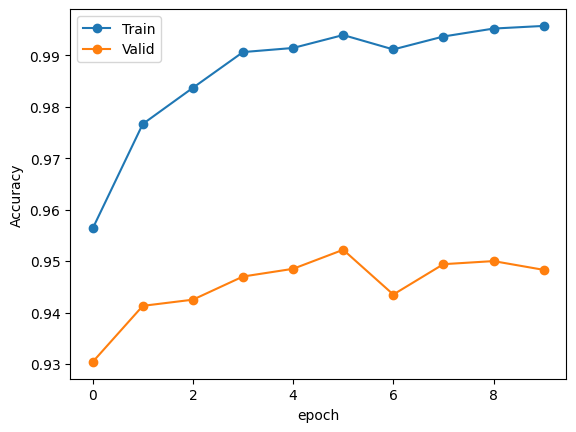

In [10]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_10.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.0214235494289015, 0.9934571428571428)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.15525178428739309, 0.9504)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=p
each_accu

airplane      0.997420
automobile    0.994532
bird          0.993925
cat           0.983654
deer          0.997719
dog           0.989130
frog          0.997446
horse         0.988296
ship          0.996346
truck         0.996005
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(5).index.map(trainset.dataset.classess)]
targetF

[3, 7, 5, 2, 1]

In [17]:
targetF=[0,1,8,9]

In [18]:
 #將資料切分成true and false
def split_data(model_0,data_dl,split_mode):
    model_0.eval()
    indexF=[]
    indexT=[]
    with torch.no_grad():
        for (data,target,idx) in data_dl:
            data,target=data.cuda(),target.cuda()
            out = model_0(data)
            _, y_pred_tag = torch.max(out, dim = 1) 
            criterion = nn.CrossEntropyLoss(reduction='none')
            loss = criterion(out, target)
            softmax = torch.softmax(out, dim=1)
            # print(loss)
            for idx,loss,t,pred ,softmax in zip(idx,loss,target,y_pred_tag,softmax):
                if(split_mode[0]=='loss'):    
                    if(loss>split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    # elif(loss>split_mode[1] and loss<split_mode[0]):
                    #    indexF.append(idx.cpu().numpy().item())  
                    #    indexT.append(idx.cpu().numpy().item())
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                elif(split_mode=='TandF'):
                    
                    if(t!=pred):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())
                     
                   
                elif(split_mode[0]=='softmax'):
                 
                    if(softmax.max()<split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                    else:
                        indexT.append(idx.cpu().numpy().item())  
                     

                elif(split_mode[0]=='classaccu'):
                    if(t in split_mode[1]):
                        indexF.append(idx.cpu().numpy().item())  
                        data_dl.dataset.dataset.update_flag(idx)
                        if(t==0):
                            indexT.append(idx.cpu().numpy().item()) 
                    else:
                        indexT.append(idx.cpu().numpy().item()) 
                    

            torch.cuda.empty_cache() 
        return indexF,indexT

In [19]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(14025, 24463)

In [20]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(4006, 6987)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i,d,t in zip(idx,data,target):
                if(t!=0):
                    flat_true.append(int(data_dl.dataset.dataset.flag[i]))
                    flat_data.append(d.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [24]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,class_weight=None,trainclassnum=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.fc=nn.Linear(model.fc.in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
        model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]
        
    # for param in model.parameters():
    #     param.requires_grad = False

    # for param in model_fc_layer.parameters():
    #     param.requires_grad = True

    if(data_name=="decision"):
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        # dense1 = nn.Linear(9216, 224 * 224 * 3)
        # reshape = nn.Unflatten(-1,(3,224, 224))
        # model=nn.Sequential(dense1,reshape,model)
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    # torch.save(model, f"model_{model_algo}_{data_name}.pth")
    torch.cuda.empty_cache() 
    return model


Epoch=0,train_loss=0.0047242194162629685,train_accu=0.998984513835999
Epoch=0,valid_loss=0.012295334332636442,valid_accu=0.9960031086932386
0
Epoch=1,train_loss=0.003293876353445571,train_accu=0.9988575780654989
Epoch=1,valid_loss=0.015044240207075529,valid_accu=0.9957810591761963
Epoch=2,train_loss=0.002063184356326501,train_accu=0.9993018532622493
Epoch=2,valid_loss=0.01261518270080538,valid_accu=0.9960031086932386
Epoch=3,train_loss=0.004514858034597563,train_accu=0.9983498349834984
Epoch=3,valid_loss=0.021534256508931062,valid_accu=0.9937826135228156
Epoch=4,train_loss=0.003561196629478827,train_accu=0.998984513835999
Epoch=4,valid_loss=0.01603467361990594,valid_accu=0.9950038858665482
4 Early stopping!


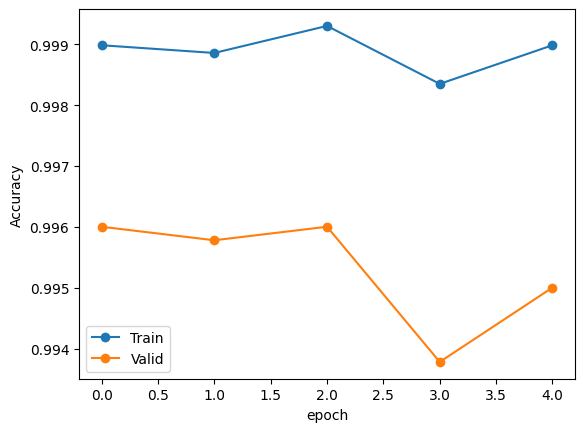

In [25]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

In [26]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.028140584075270945,train_accu=0.9933368760985979
Epoch=0,valid_loss=0.16255143490496393,valid_accu=0.9467582653499356
0
Epoch=1,train_loss=0.02308232015836272,train_accu=0.9936230225238115
Epoch=1,valid_loss=0.1780047755178181,valid_accu=0.9434664376699585
Epoch=2,train_loss=0.013656483638646145,train_accu=0.9964844867759474
Epoch=2,valid_loss=0.17789564611310524,valid_accu=0.9457564047516817
Epoch=3,train_loss=0.009386907078842025,train_accu=0.9976699505375465
Epoch=3,valid_loss=0.15880898374063632,valid_accu=0.9514813224559897
0
Epoch=4,train_loss=0.013544707172251216,train_accu=0.9956669255610514
Epoch=4,valid_loss=0.193042176005597,valid_accu=0.9433233147273508
Epoch=5,train_loss=0.008554835293983529,train_accu=0.9976699505375465
Epoch=5,valid_loss=0.18449985491160126,valid_accu=0.9480463718334049
Epoch=6,train_loss=0.011143819477101666,train_accu=0.9970976576871193
Epoch=6,valid_loss=0.19251291049798705,valid_accu=0.9430370688421353
Epoch=7,train_loss=0.014254

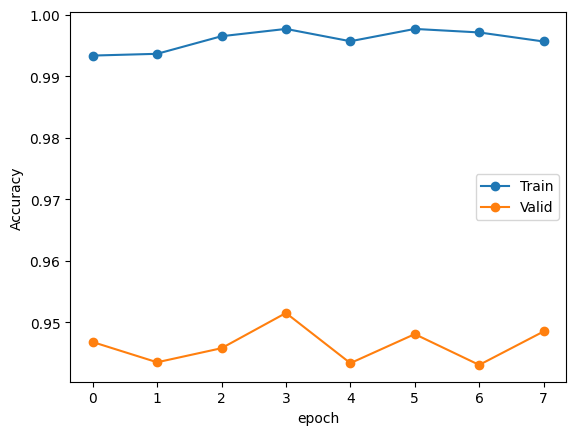

In [27]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [28]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 150, 150]           9,408
       BatchNorm2d-2         [-1, 64, 150, 150]             128
       BasicConv2d-3         [-1, 64, 150, 150]               0
         MaxPool2d-4           [-1, 64, 75, 75]               0
            Conv2d-5           [-1, 64, 75, 75]           4,096
       BatchNorm2d-6           [-1, 64, 75, 75]             128
       BasicConv2d-7           [-1, 64, 75, 75]               0
            Conv2d-8          [-1, 192, 75, 75]         110,592
       BatchNorm2d-9          [-1, 192, 75, 75]             384
      BasicConv2d-10          [-1, 192, 75, 75]               0
        MaxPool2d-11          [-1, 192, 37, 37]               0
           Conv2d-12           [-1, 64, 37, 37]          12,288
      BatchNorm2d-13           [-1, 64, 37, 37]             128
      BasicConv2d-14           [-1, 64,

Epoch=0,train_loss=0.012523493195805905,train_accu=0.9985739750445632
Epoch=0,valid_loss=0.0721142244959065,valid_accu=0.9762855716425362
0
Epoch=1,train_loss=0.009584606183749256,train_accu=0.9982174688057041
Epoch=1,valid_loss=0.08253815870023463,valid_accu=0.9772840738891663
0
Epoch=2,train_loss=0.0057854191958074215,train_accu=0.9989304812834224
Epoch=2,valid_loss=0.07496873305419914,valid_accu=0.9765351972041937
Epoch=3,train_loss=0.005971281981870114,train_accu=0.9988591800356507
Epoch=3,valid_loss=0.07826892543106126,valid_accu=0.9742885671492761
Epoch=4,train_loss=0.005532791021042594,train_accu=0.9987165775401069
Epoch=4,valid_loss=0.08654662892589726,valid_accu=0.9725411882176734
Epoch=5,train_loss=0.0028741981298662724,train_accu=0.9995008912655972
Epoch=5,valid_loss=0.08548506904677992,valid_accu=0.9752870693959061
4 Early stopping!


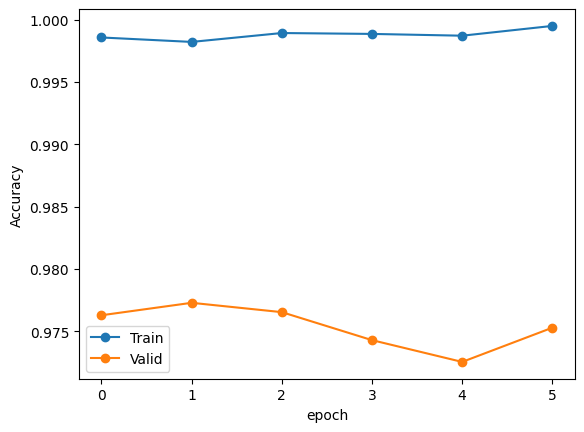

In [29]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [30]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0047242194162629685, 0.998984513835999)

In [31]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.012295334332636442, 0.9960031086932386)

In [32]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.0093899995383682, 0.9977517066590361)

In [33]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.0107373735231784, 0.9977183600713012)

In [34]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.16118602546651586, 0.9523400601116359)

In [35]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.0816791568128592, 0.9762855716425362)

In [36]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.010787438175667609, 0.9976, 14025)

In [37]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.13629992629736662, 0.9584, 4006)

In [38]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.020539735700136848, 0.9967428571428572, 11882, 23118)

In [39]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.16556664009653033, 0.956, 3389, 6611)

In [40]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [41]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.021424,0.993457,0.155252,0.950400
1,Model_Decision,0.004724,0.998985,0.012295,0.996003
2,Model_T,0.009390,0.997752,0.161186,0.952340
3,Model_F,0.010737,0.997718,0.081679,0.976286
4,Total_Model,0.020540,0.996743,0.165567,0.956000
5,Total_Model_without_decision,0.010787,0.997600,0.136300,0.958400


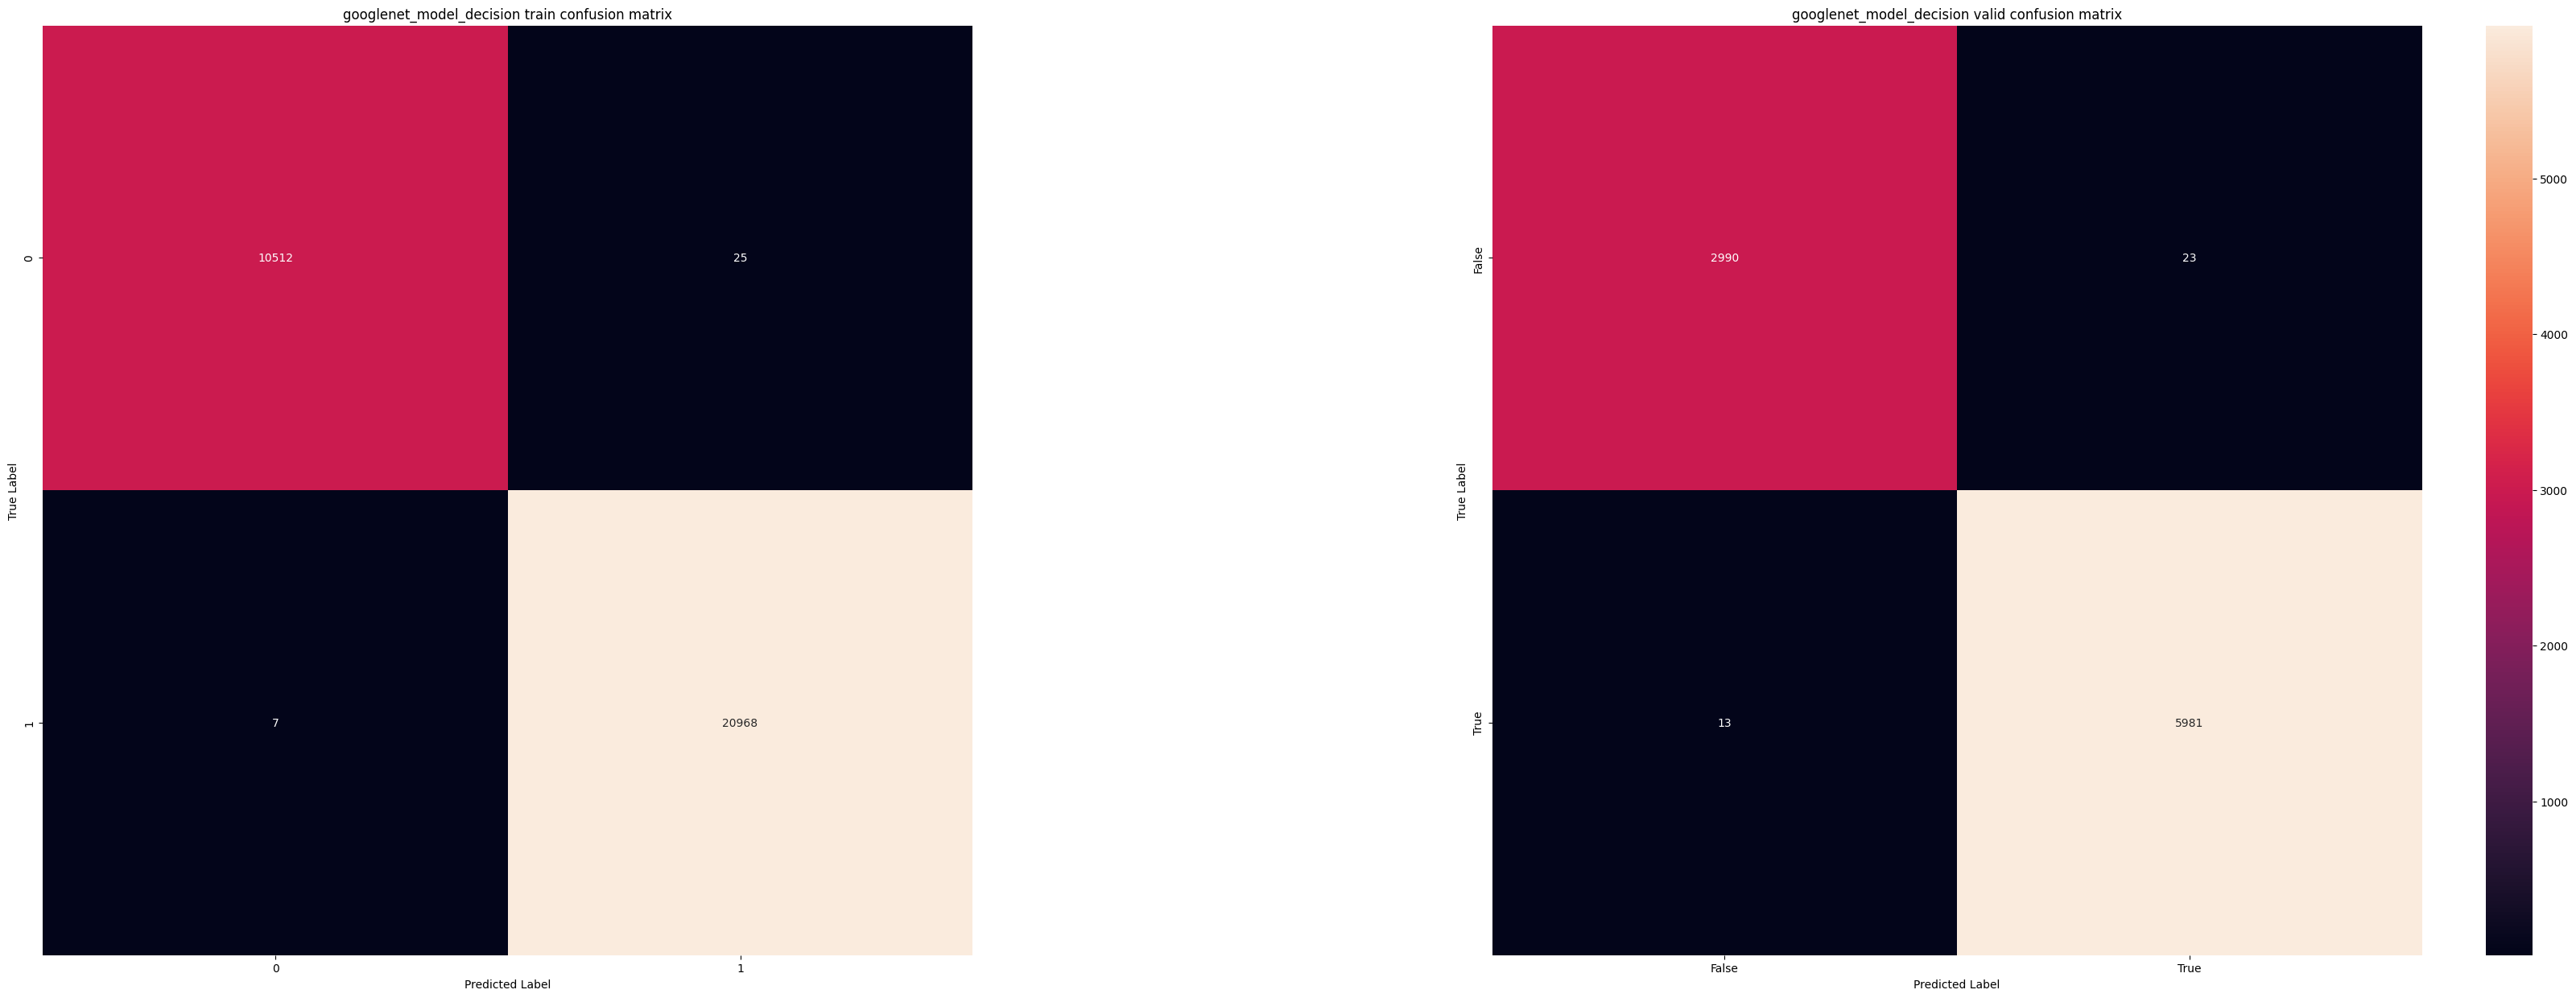

In [42]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

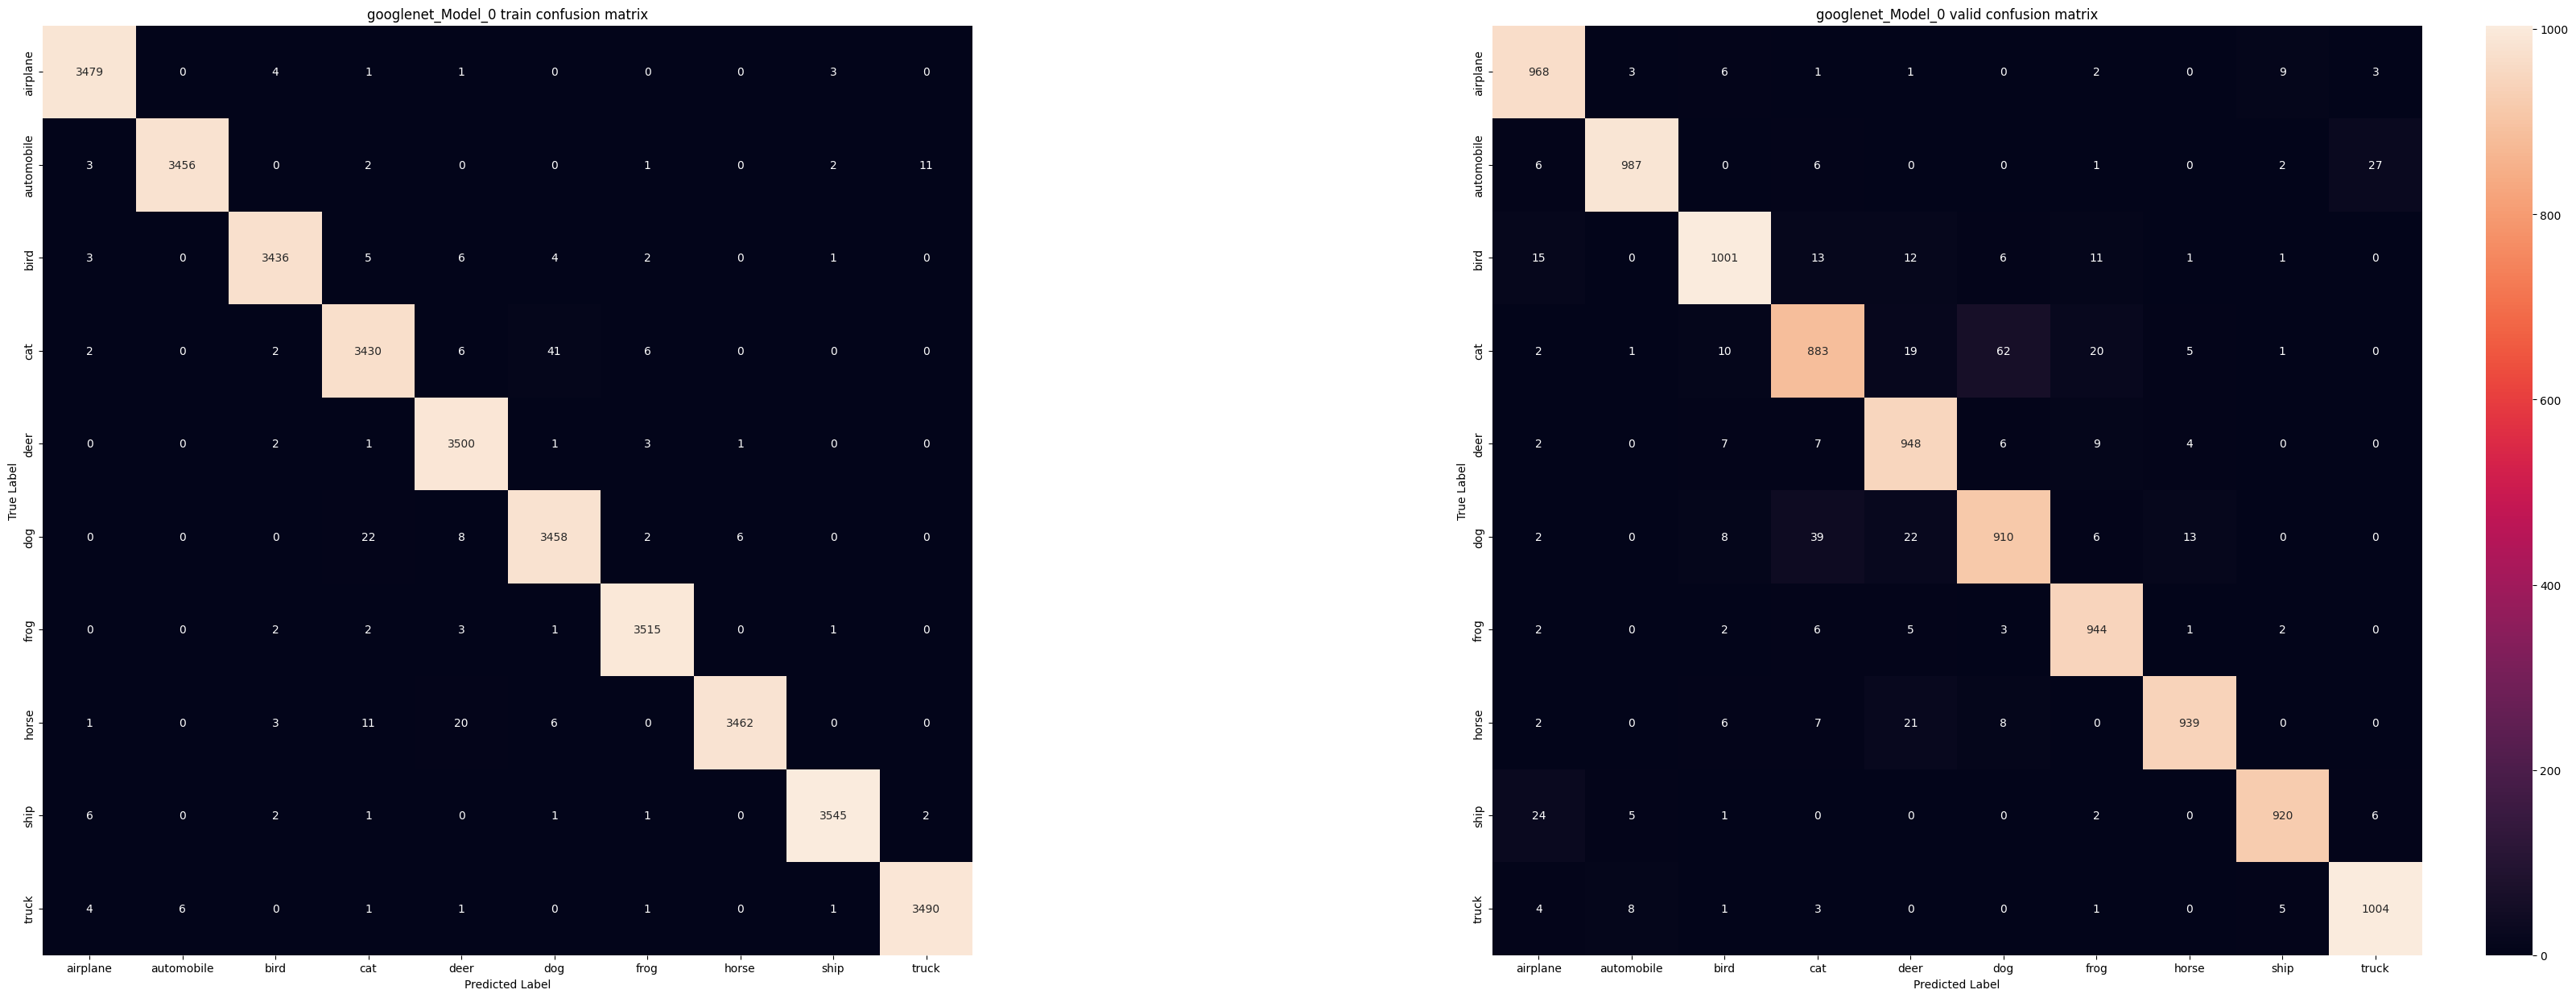

In [43]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

In [44]:
def calculate_confusion(confusion_matrix, N):
    n_classes = confusion_matrix.shape[0]
    confusion_degrees = np.zeros((n_classes, n_classes), dtype=float)
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                degree = (confusion_matrix.iloc[i, j] / np.sum(confusion_matrix.iloc[i])) + \
                        (confusion_matrix.iloc[j, i] / np.sum(confusion_matrix.iloc[j]))
                confusion_degrees[i, j] = degree
    
    # 只检查下三角的元素
    indices = np.tril_indices_from(confusion_degrees, k=-1)
    flat_indices = np.argsort(confusion_degrees[indices])[::-1]
    row_indices = indices[0][flat_indices]
    col_indices = indices[1][flat_indices]
    
    top_elements = confusion_degrees[row_indices, col_indices]
    top_positions = list(zip(row_indices, col_indices))

    print("Top", N, "Elements:")
    print(top_elements[:N])
    print("Top", N, "Positions:")
    print(top_positions[:N])
    
    return top_elements, top_positions

In [45]:
top_elements, top_positions=calculate_confusion(confusion_matrix_train,N=15)

Top 15 Elements:
[0.01805086 0.00599445 0.0048778  0.00342906 0.00314017 0.00257339
 0.00254643 0.00230573 0.00228821 0.0020199  0.00201459 0.00200574
 0.00170649 0.00115707 0.00114607]
Top 15 Positions:
[(5, 3), (7, 4), (9, 1), (7, 5), (7, 3), (5, 4), (8, 0), (4, 2), (6, 3), (3, 2), (2, 0), (4, 3), (6, 4), (5, 2), (6, 2)]


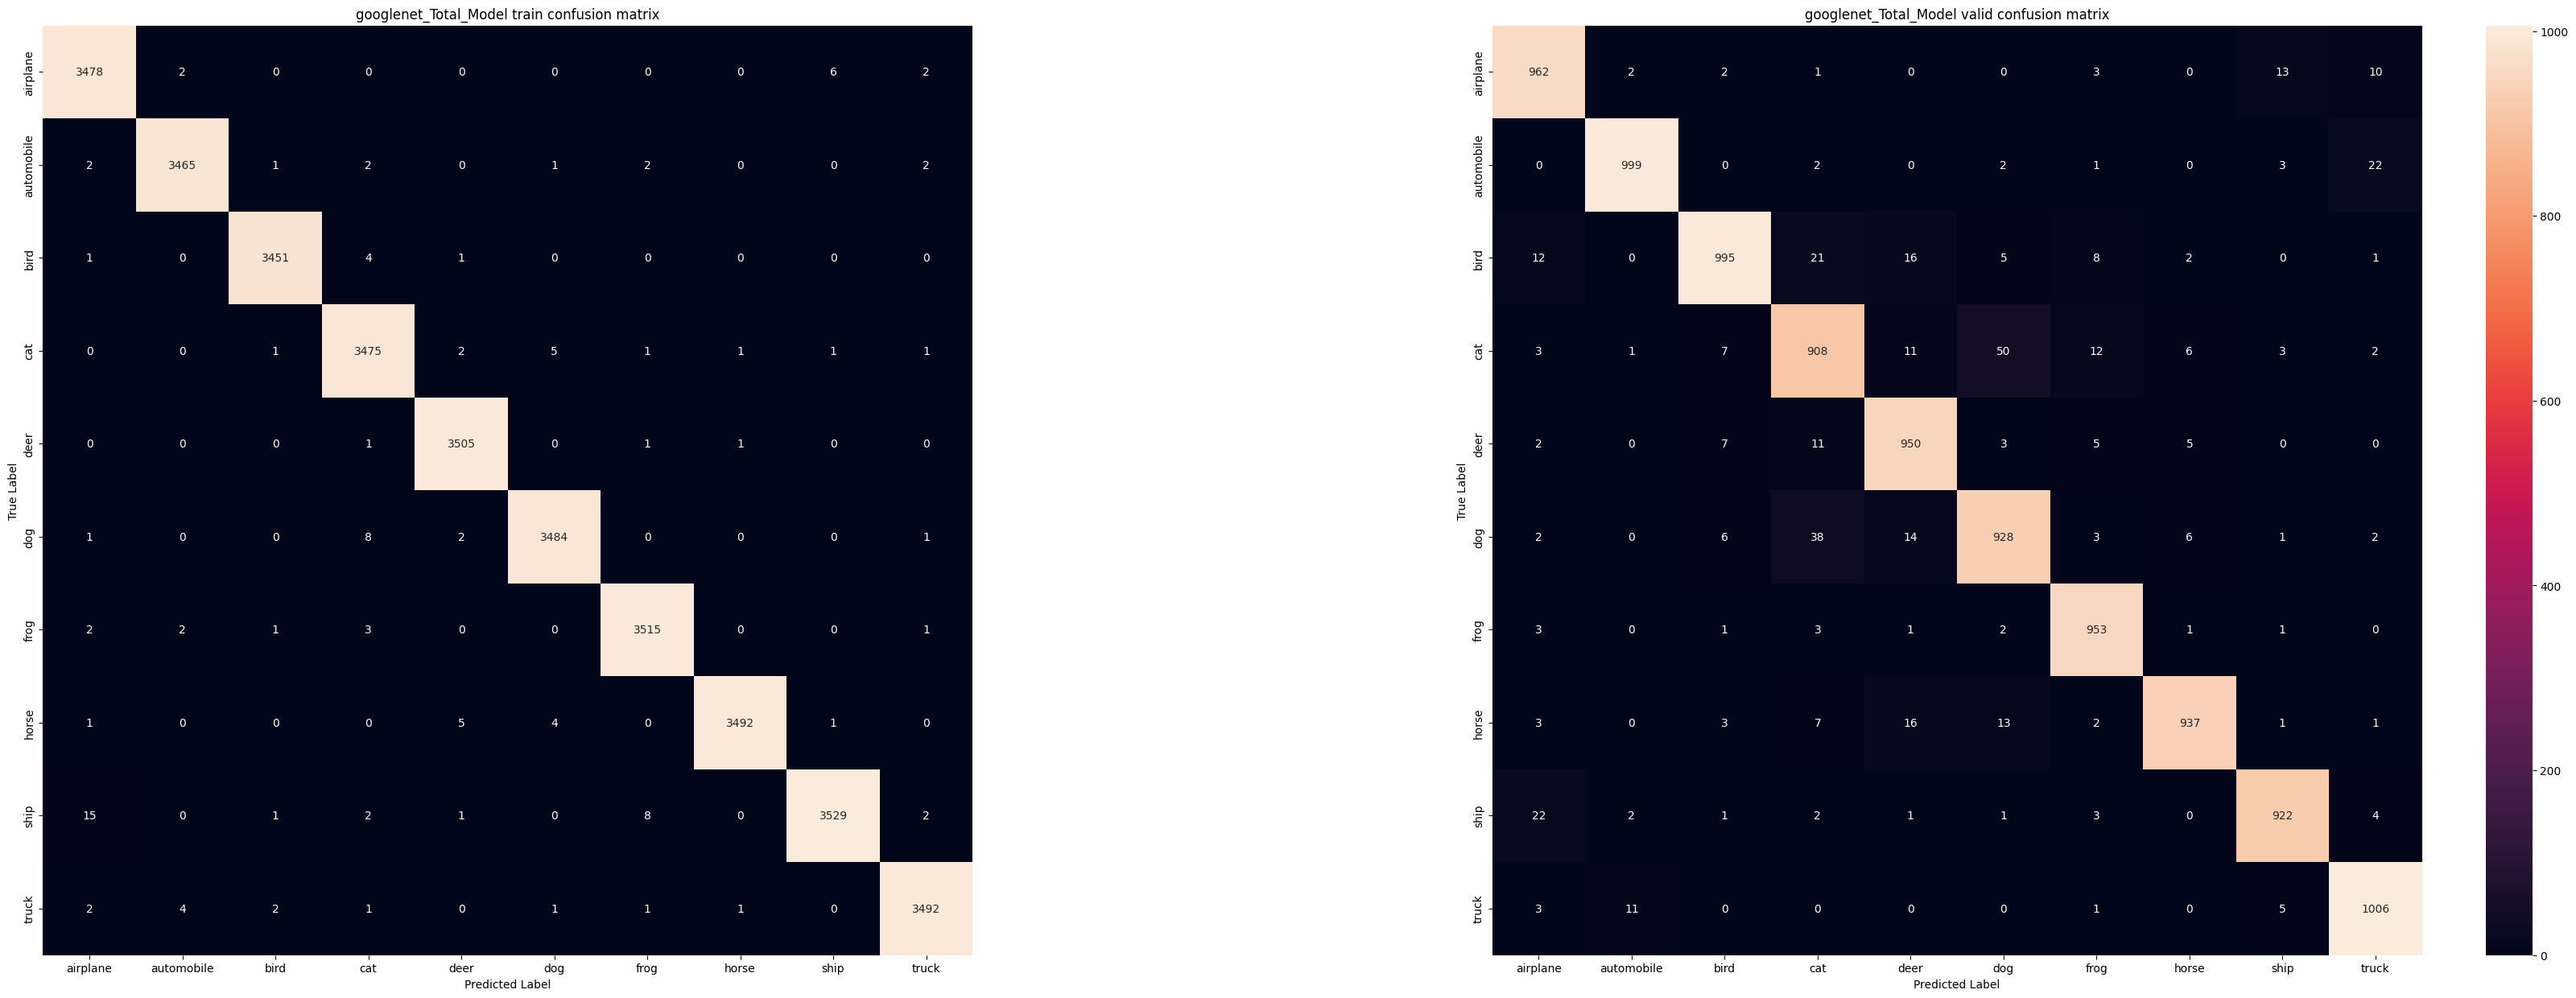

In [46]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

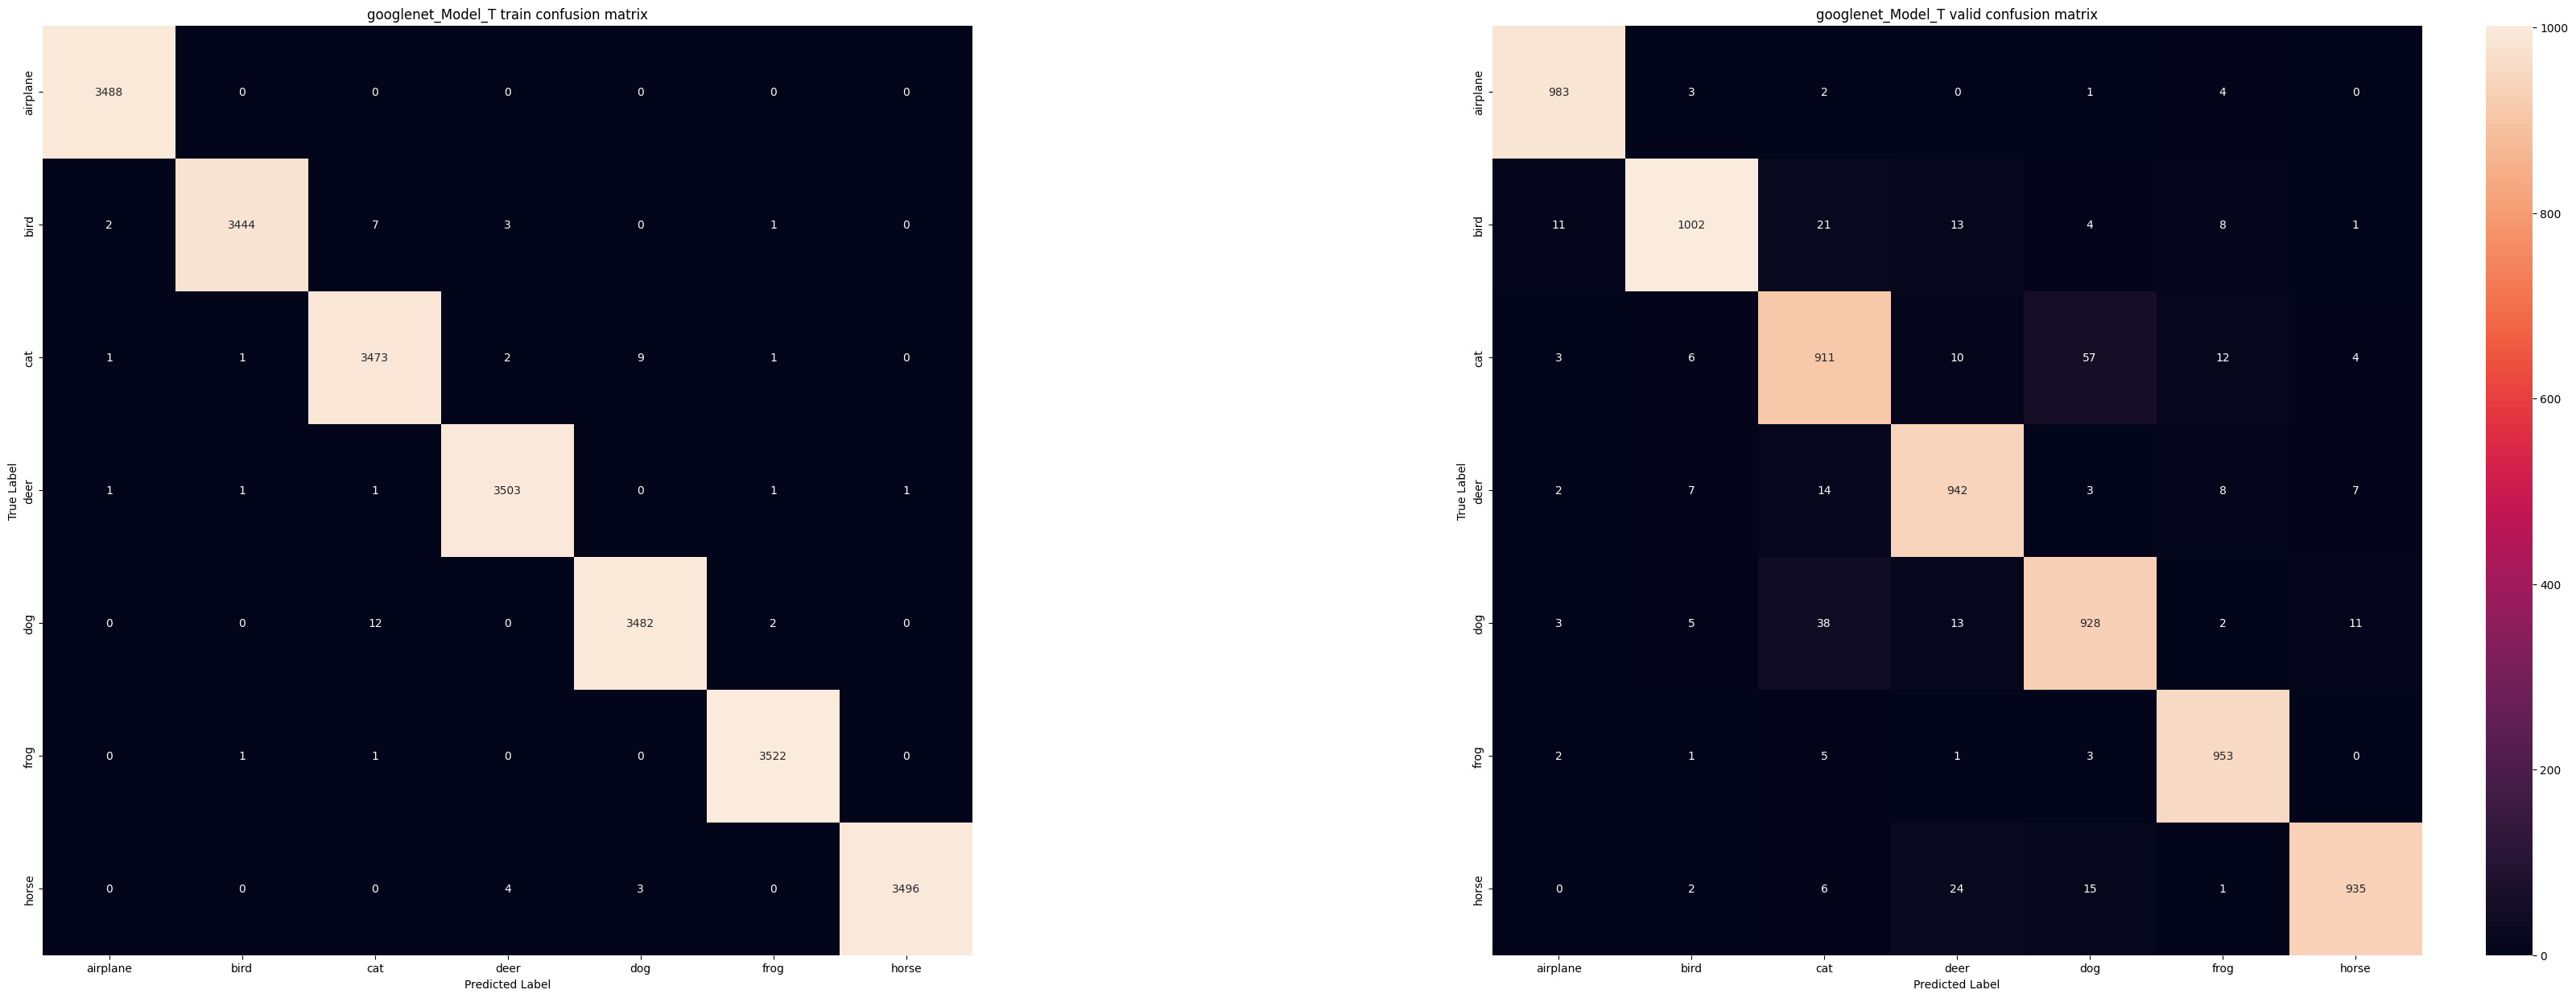

In [47]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

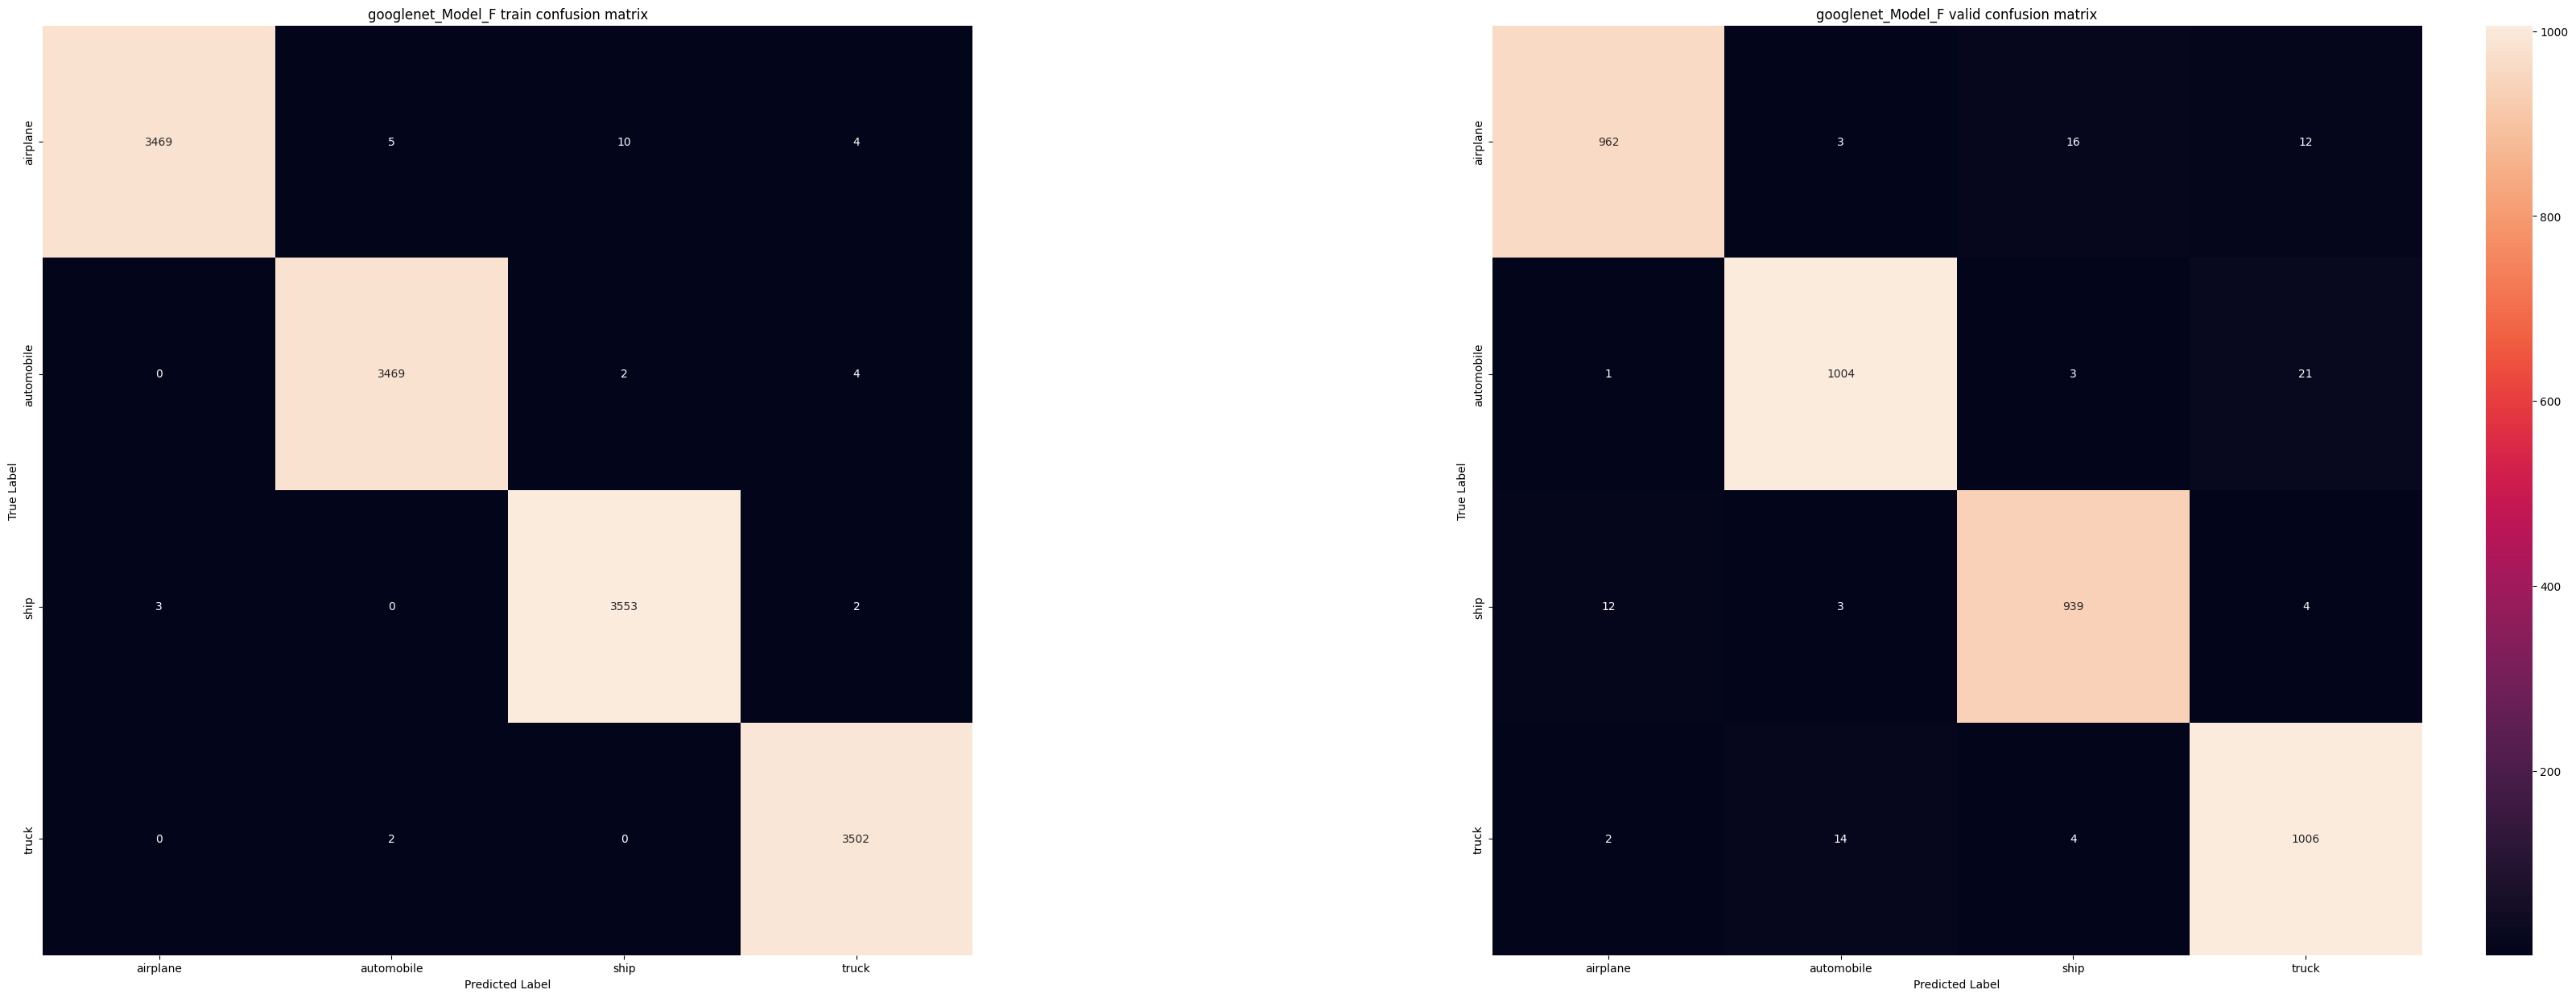

In [48]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [49]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [50]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,27599,2,0,2,2,0.985080,0.999708,0.997527,0.999946,False,True,True,True,True
1,15294,6,0,6,6,0.713200,0.999670,0.999978,0.999980,False,True,True,True,True
2,32323,8,8,5,8,0.990008,0.876680,0.999233,0.999015,True,False,True,False,False
3,46178,9,9,0,9,0.999825,0.426005,0.999934,0.999992,True,False,True,False,False
4,31715,0,0,0,0,0.988497,0.999967,0.999990,0.615992,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,32734,0,0,0,0,0.999659,0.999863,0.999862,0.898314,True,True,True,True,False
34996,3896,5,0,5,5,0.915526,0.988162,0.948579,0.999891,False,True,True,True,True
34997,38191,9,9,5,9,0.999400,0.275561,0.999960,0.999998,True,False,True,False,False
34998,27291,9,9,5,9,0.999314,0.689853,0.999885,0.999949,True,False,True,False,False


In [51]:
df_results[(df_results['Target']==0)&(df_results['Match_F']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
2074,45232,0,8,0,0,0.534654,0.999976,0.995225,0.998497,False,True,True,False,False
5296,45615,0,9,0,0,0.471382,0.999887,0.999788,0.703562,False,True,True,True,False
8597,49517,0,8,0,0,0.960038,0.999975,0.999923,0.961877,False,True,True,False,False
9564,21721,0,8,0,0,0.758124,0.999715,0.989504,0.515116,False,True,True,True,False
12411,43750,0,8,0,0,0.599494,0.999980,0.967455,0.996417,False,True,True,False,False
12759,8553,0,9,0,0,0.657498,0.999997,0.951338,0.657637,False,True,True,False,False
15222,47799,0,9,0,0,0.839640,0.999963,0.999248,0.999731,False,True,True,False,False
16335,37867,0,8,0,0,0.522195,0.999934,0.995816,0.997985,False,True,True,True,False
17558,46756,0,8,0,0,0.753650,0.999970,0.973879,0.765382,False,True,True,True,False
19058,11424,0,8,0,0,0.846674,0.999864,0.888548,0.962439,False,True,True,False,False


In [52]:
df_results[(df_results['Target']==0)&(df_results['Decision']!=True)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
28,11612,0,0,0,0,0.999191,0.999992,0.999984,0.999723,True,True,True,False,False
69,14652,0,0,0,0,0.998783,0.999899,0.999563,0.526675,True,True,True,False,False
86,37955,0,0,0,0,0.894997,0.999706,0.999381,0.978276,True,True,True,False,False
92,3647,0,0,0,0,0.977652,0.999748,0.999901,0.995179,True,True,True,False,False
141,11879,0,0,0,0,0.999634,0.999982,0.999901,0.850197,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34896,42597,0,0,0,0,0.983329,0.999981,0.999730,0.970897,True,True,True,False,False
34899,25714,0,0,0,0,0.990221,0.999923,0.999792,0.992969,True,True,True,False,False
34966,49498,0,8,0,0,0.533237,0.999624,0.999783,0.999431,False,True,True,False,False
34969,14945,0,0,0,0,0.999678,0.999996,0.999999,0.509332,True,True,True,False,False


In [53]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,31715,0,0,0,0,0.988497,0.999967,0.999990,0.615992,True,True,True,True,False
29,19004,0,0,0,0,0.995340,0.988254,0.967770,0.966030,True,True,True,True,False
88,46614,0,0,0,0,0.996112,0.988787,0.996037,0.999173,True,True,True,True,False
133,2720,0,0,0,0,0.999936,0.999547,0.999904,0.989200,True,True,True,True,False
144,49723,0,0,0,0,0.999226,0.997893,0.988300,0.975473,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34946,49441,0,0,0,0,0.999424,0.999834,0.999826,0.630128,True,True,True,True,False
34950,47834,0,0,0,0,0.999492,0.999896,0.992998,0.936785,True,True,True,True,False
34958,24163,0,0,0,0,0.998043,0.999919,0.999908,0.998724,True,True,True,True,False
34965,13459,0,0,0,0,0.999762,0.999982,0.999766,0.998181,True,True,True,True,False


In [54]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

0    2126
8      26
9      12
1       6
7       6
6       4
5       3
3       3
Name: Target, dtype: int64

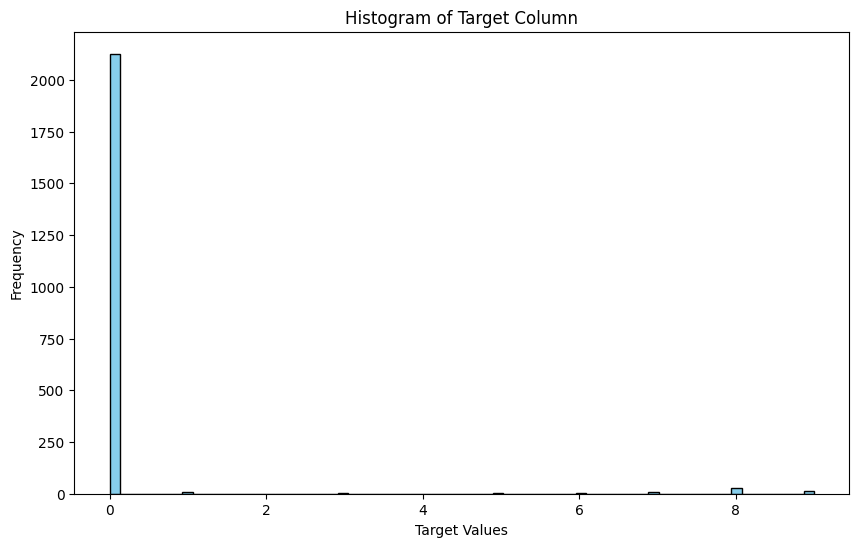

In [55]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [56]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

114

In [57]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

12

In [58]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
4,31715,0,0,0,0,0.988497,0.999967,0.999990,0.615992,True,True,True,True,False
179,22777,0,0,0,0,0.998817,0.997449,0.998647,0.782170,True,True,True,True,False
200,48587,0,0,0,0,0.999530,0.999978,0.999981,0.629088,True,True,True,True,False
218,24583,0,0,0,0,0.998179,0.999895,0.999867,0.858778,True,True,True,True,False
364,40741,0,0,0,0,0.999294,0.999903,0.999911,0.606864,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34781,35132,0,0,0,0,0.999317,0.999992,0.999988,0.647405,True,True,True,True,False
34882,2421,0,0,0,0,0.994406,0.999992,0.999888,0.615287,True,True,True,True,False
34921,40320,0,0,0,0,0.989025,0.999928,0.999930,0.602554,True,True,True,True,False
34946,49441,0,0,0,0,0.999424,0.999834,0.999826,0.630128,True,True,True,True,False


In [59]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,14119,5,0,4,4,0.969725,0.972367,0.870801,0.999925,False,False,False,True,True
1,38241,5,0,5,5,0.685738,0.999807,0.999959,0.999900,False,True,True,True,True
2,1233,9,9,0,9,0.995053,0.961672,0.999105,0.999677,True,False,True,False,False
3,28725,3,0,3,3,0.490230,0.999464,0.979872,0.999841,False,True,True,True,True
4,8819,2,0,2,2,0.933638,0.940782,0.771009,0.999979,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49150,1,1,0,1,0.993199,0.772860,0.999807,0.999992,True,False,True,False,False
9996,2466,1,1,5,1,0.999062,0.323140,0.999995,0.999347,True,False,True,False,False
9997,32865,8,8,0,8,0.994705,0.710818,0.997992,0.993106,True,False,True,False,False
9998,402,2,0,2,2,0.878815,0.999349,0.999720,0.999884,False,True,True,True,True


In [60]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

42

In [61]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

8

In [62]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
8,35846,0,0,0,0,0.999672,0.999979,0.999996,0.614598,True,True,True,True,False
11,27338,0,0,0,0,0.999832,0.999966,0.999995,0.630738,True,True,True,True,False
28,17355,0,0,0,0,0.998068,0.999479,0.999681,0.999033,True,True,True,True,False
32,15077,0,0,0,0,0.997183,0.999866,0.981836,0.999194,True,True,True,True,False
61,8934,0,0,0,0,0.996151,0.999779,0.999015,0.919375,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9927,31249,0,0,0,0,0.999138,0.999943,0.999879,0.965061,True,True,True,True,False
9939,37178,0,0,0,0,0.999182,0.999979,0.999972,0.575168,True,True,True,True,False
9950,19728,0,0,0,0,0.998737,0.998783,0.926313,0.998359,True,True,True,True,False
9960,3842,0,0,0,0,0.999422,0.999839,0.999942,0.928607,True,True,True,True,False


In [76]:
df_results_v[(df_results_v['Target']==0)&(df_results_v['Match_F']!=True)&(df_results_v['Decision']==False)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
449,40867,0,9,0,0,0.877383,0.999747,0.991249,0.994471,False,True,True,False,False
781,2675,0,8,0,0,0.989661,0.999032,0.590128,0.999614,False,True,True,False,False
1802,42543,0,9,0,0,0.715071,0.994850,0.666436,0.990312,False,True,True,False,False
2530,42952,0,8,0,0,0.577824,0.999951,0.535241,0.997447,False,True,True,False,False
3184,33654,0,9,0,1,0.894105,0.935022,0.814063,0.996829,False,True,False,False,False
3321,8376,0,8,0,0,0.789405,0.920532,0.469147,0.579546,False,True,True,False,False
3496,37250,0,8,0,0,0.869258,0.999619,0.642691,0.999856,False,True,True,False,False
3652,27623,0,9,0,9,0.743311,0.999684,0.596366,0.996510,False,True,False,False,False
3914,21095,0,8,0,0,0.772880,0.999490,0.755772,0.997752,False,True,True,False,False
3937,9287,0,8,0,0,0.691881,0.999998,0.990085,0.999451,False,True,True,False,False


In [64]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

0    598
8     16
3      5
7      4
1      4
9      3
5      3
6      1
Name: Target, dtype: int64

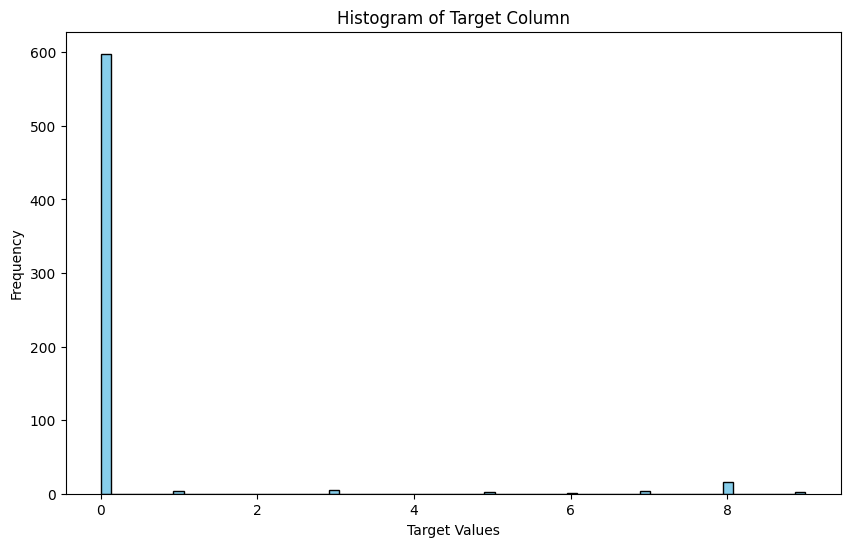

In [65]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [66]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])& (abs(df_results_v['Softmax_F']-df_results_v['Softmax_T'])>0.2)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
633,6143,8,8,7,8,0.994597,0.516325,0.789714,0.746340,True,False,True,True,False
994,5988,0,0,0,0,0.999256,0.703574,0.999795,0.998957,True,True,True,True,False
1059,349,0,0,6,0,0.998239,0.616622,0.939023,0.997313,True,False,True,True,False
1304,36049,0,0,2,0,0.999817,0.609031,0.817805,0.968413,True,False,True,True,False
1728,24113,0,9,0,0,0.591824,0.997306,0.994333,0.984529,False,True,True,True,False
1908,45188,0,9,0,0,0.713343,0.996725,0.981115,0.815696,False,True,True,True,False
1910,3932,9,9,0,9,0.985328,0.278678,0.674138,0.680416,True,False,True,True,False
2202,31974,3,0,3,5,0.510322,0.958587,0.610631,0.592040,False,True,False,False,True
2489,8174,1,1,3,3,0.903721,0.562935,0.859589,0.756236,True,False,False,True,False
2782,1674,0,0,0,0,0.992587,0.695663,0.955883,0.976618,True,True,True,True,False


In [67]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
8,35846,0,0,0,0,0.999672,0.999979,0.999996,0.614598,True,True,True,True,False
11,27338,0,0,0,0,0.999832,0.999966,0.999995,0.630738,True,True,True,True,False
28,17355,0,0,0,0,0.998068,0.999479,0.999681,0.999033,True,True,True,True,False
32,15077,0,0,0,0,0.997183,0.999866,0.981836,0.999194,True,True,True,True,False
61,8934,0,0,0,0,0.996151,0.999779,0.999015,0.919375,True,True,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9927,31249,0,0,0,0,0.999138,0.999943,0.999879,0.965061,True,True,True,True,False
9939,37178,0,0,0,0,0.999182,0.999979,0.999972,0.575168,True,True,True,True,False
9950,19728,0,0,0,0,0.998737,0.998783,0.926313,0.998359,True,True,True,True,False
9960,3842,0,0,0,0,0.999422,0.999839,0.999942,0.928607,True,True,True,True,False


In [68]:
# #全部模型裝在一起的表現
# def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
#     total_loss = 0
#     accu = 0
#     flat_true=[]
#     flat_pred=[]
#     sum_F=0
#     sum_T=0
#     with torch.no_grad():
#         for data,target,idx in data_dl:
#             outputs=[]
#             data,target=data.to(device),target.to(device)
#             out_growth = model_0(data)
#             softmax_0=torch.softmax(out_growth, dim=1)

#             out_T = model_T(data)
#             softmax_T=torch.softmax(out_T, dim=1)

#             out_F = model_F(data)
#             softmax_F=torch.softmax(out_F, dim=1)

         
            
#             for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
#                 st_max=torch.max(st).item()
#                 sf_max=torch.max(sf).item()

#                 out_decision=model_decision(d.unsqueeze(0))
#                 _, pred = torch.max(out_decision, dim = 1) 
#                 softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
#                 if(softmax_decision<0.9):
#                     # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
#                     # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
#                     if(sf_max>st_max):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1
#                 else:
                   
#                     if(pred==0):
#                         outputs.append(model_F(d.unsqueeze(0)))
#                         sum_F+=1
#                     else:
#                         outputs.append(model_T(d.unsqueeze(0)))
#                         sum_T+=1

#             outputs = torch.cat(outputs, dim=0)
#             _, y_pred_tag = torch.max(outputs, dim = 1)
#             loss = criterion(outputs, target)


#             flat_true.extend(target.cpu().numpy())
#             flat_pred.extend(y_pred_tag.cpu().numpy())

#             total_loss+= loss.item()*data.size(0)
#             correct=torch.sum(y_pred_tag == target).item()
#             accu += correct      

#     total_loss=total_loss/size
#     accu=accu/size
#     idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
#     confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
#     return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [69]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(sf_max-st_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [70]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.027190421027530515, 0.9963142857142857, 11884, 23116)

In [71]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.2643746941097081, 0.9495, 3474, 6526)

In [72]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score
#模型表現
def evaluate_metric_model(model,data_dl,size,data_name,mode=None):
        
        model.to(device)
        torch.cuda.empty_cache()
        total_loss = 0
        accu = 0
        flat_true=[]
        flat_pred=[]
        with torch.no_grad():
            model.eval()   
            for data, target,idx in data_dl:
                    
                    data,target=data.to(device),target.to(device)
                    out= model(data)
                    _, y_pred_tag = torch.max(out, dim = 1)

                    loss = criterion(out, target)
                    # print(target)
                    flat_true.extend(target.cpu().numpy())
                    flat_pred.extend(y_pred_tag.cpu().numpy())

                    total_loss+= loss.item()*data.size(0)
                    correct=torch.sum(y_pred_tag == target).item()
                    accu += correct      

            total_loss=total_loss/size
            accu=accu/size

        # 计算各种指标
        precision = precision_score(flat_true, flat_pred, average='macro')
        recall = recall_score(flat_true, flat_pred, average='macro')
        f1 = f1_score(flat_true, flat_pred, average='macro')
        

        a=sorted(set(flat_true))
        if(mode=='eval'):
            if(data_name=='decision'):
                confusion_matrix_valid=pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a))
            else:
                idxtoclass={v:k for k,v in data_dl.dataset.dataset.classes}
                confusion_matrix_valid= pd.DataFrame(confusion_matrix(flat_true, flat_pred),columns=list(a),index=list(a)).rename(columns=idxtoclass,index=idxtoclass)
            return total_loss,accu,confusion_matrix_valid
        else:
            return total_loss,accu,precision,recall,f1

In [73]:
evaluate_metric_model(model_0,train_dl,train_size,"0",mode=None)

(0.020888336233901125,
 0.9939142857142858,
 0.9939239139599506,
 0.9939023357452388,
 0.993907036403942)

In [74]:
evaluate_metric_model(model_0,valid_dl,valid_size,"0",mode=None)

(0.1549451125573367,
 0.9513,
 0.9514175620205536,
 0.9514718909025449,
 0.9512918852890955)